**1. Import Library**

In [ ]:
!pip install micromlgen

# Library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing data
from sklearn.model_selection import train_test_split

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Pengujian Metrik
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Micromlgen
import micromlgen

# Google drive
from google.colab import drive

**2. Preprocessing Data**

In [ ]:
# Ambil dataset melalui URL
data_url = "https://raw.githubusercontent.com/blacksonatae/Smart_Irigation_Dataset/main/Soil%20Moisture%2C%20Air%20Temperature%20and%20humidity%2C%20and%20Water%20Motor%20onoff%20Monitor%20data.AmritpalKaur.csv"

# Membaca dan menyimpan dataset ke dalam variable dalam bentuk data frame
data_irigation = pd.read_csv(data_url)

# Tampilkan 10 baris data
print(data_irigation.head(10))

   Soil Moisture  Temperature  Air Humidity  Pump Data
0     683.802906    29.184908     71.789699          0
1     408.571567    33.707205     77.977391          1
2     659.092074    24.760311     60.776282          1
3     842.929764    32.738515     59.323543          0
4     414.199320    25.692744     66.624914          1
5     487.521226    33.806809     47.774693          1
6     820.856733    32.659495     40.317592          0
7     726.504807    38.083939     50.915951          0
8     939.915978    35.430747     60.822721          0
9     628.397718    34.232923     42.994402          1


In [ ]:
# 1. Periksa missing value pada dataset irigasi
missing_values = data_irigation.isnull().sum()

# Tampilkan jumlah indikasi missing value pada fitur data
print("Jumlah sampel yang terindikasi missing value\npada fitur data:\n")
print(missing_values.to_frame(name="Jumlah missing")
      .rename_axis("Fitur Data")
      .reset_index()
      .to_string(index=False))

Jumlah sampel yang terindikasi missing value
pada fitur data:

   Fitur Data  Jumlah missing
Soil Moisture               0
  Temperature               0
 Air Humidity               0
    Pump Data               0


In [ ]:
# 2. Memisahkan dataset menjadi fitur dan target
X = data_irigation[['Soil Moisture', 'Temperature', 'Air Humidity']]
y = data_irigation['Pump Data']

# 3. Membagi dataset menjadi data training dan testing
# train_size = 0.8 dan test_size=0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

In [ ]:
# Menampilkan jumlah sampel untuk training dan testing data
print("x_train shape (features): ", X_train.shape)
print("y_train shape (targets): ", y_train.shape)
print("X_test shape (features): ", X_test.shape)
print("y_test shape (targets): ", y_test.shape)

x_train shape (features):  (2400, 3)
y_train shape (targets):  (2400,)
X_test shape (features):  (600, 3)
y_test shape (targets):  (600,)


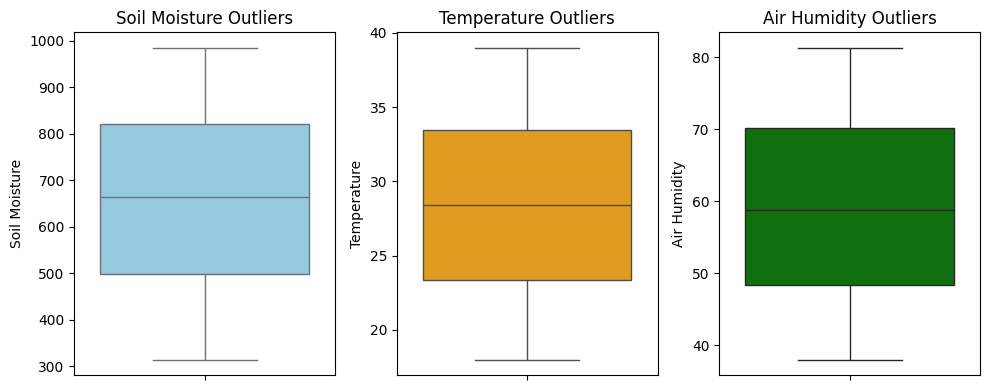

In [ ]:
# 3. Buat boxplot untuk mendeteksi outlier secara visual
fig, axes = plt.subplots(1, 3, figsize=(10,4))

# Boxplot untuk fitur Soil Moisture
sns.boxplot(data=X_train, y='Soil Moisture', ax=axes[0], color="skyblue")
axes[0].set_title('Soil Moisture Outliers')

# Boxplot untuk fitur Temperature
sns.boxplot(data=X_train, y='Temperature', ax=axes[1], color="orange")
axes[1].set_title('Temperature Outliers')

# Boxplot untuk fitur Soil Moisture
sns.boxplot(data=X_train, y='Air Humidity', ax=axes[2], color="green")
axes[2].set_title('Air Humidity Outliers')

plt.tight_layout()
plt.show()

In [ ]:
# 3.1 Hitung IQR untuk mendeteksi outlier
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

# Menghitung jumlah outlier per fitur
outliers = ((X_train < (Q1 - 1.5 * IQR)) | (X_train > (Q3 + 1.5 * IQR))).sum()

# Buat hasil outlier dalam bentuk tabel
outliers_table = pd.DataFrame({'Fitur': outliers.index, 'Jumlah Outlier' : outliers.values})

outliers_table = outliers_table.reset_index(drop=True)

print(outliers_table.to_string(index=False))

        Fitur  Jumlah Outlier
Soil Moisture               0
  Temperature               0
 Air Humidity               0


In [ ]:
# 4. Lakukan pemeriksaan keseimbangan data

# Hitung jumlah dan persentase
class_distribution = y_train.value_counts()
class_percentages = (class_distribution / len(y_train)) * 100

# Buat laporan dalam bentuk tabel
class_distribution_table = pd.DataFrame({
    "Pump Data": class_distribution.index,
    "Jumlah": class_distribution.values,
    "Persentase %": class_percentages.values
})

# Rapikan angka desimal
class_distribution_table["Persentase %"] = class_distribution_table["Persentase %"].round(2)

# Urutkan kelas
class_distribution_table = class_distribution_table.sort_values(by="Pump Data")

class_distribution_table = class_distribution_table.reset_index(drop=True)

print(class_distribution_table.to_string(index=False))

 Pump Data  Jumlah  Persentase %
         0    1133         47.21
         1    1267         52.79


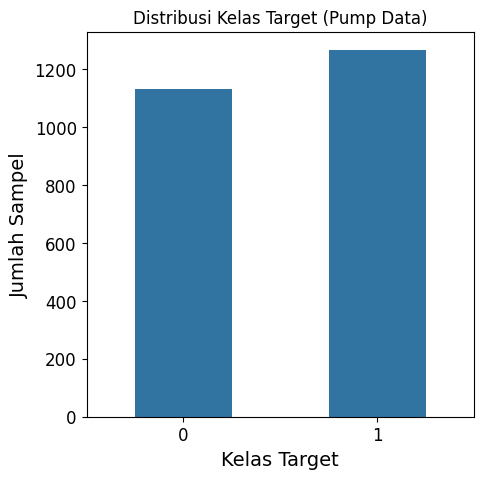

In [ ]:
# Tampilkan visualisasi distribusi kelas melalui plot
plt.figure(figsize=(5, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, width=0.5)
plt.title("Distribusi Kelas Target (Pump Data)", fontsize=12)
plt.xlabel("Kelas Target", fontsize=14)
plt.ylabel("Jumlah Sampel", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [ ]:
# 5 Pengelompokan data
# Fungsi Pengelompokan Kelembaban Tanah
def categorize_soil_moisture(moisture):
    if moisture >= 727:
        return 'Sangat Kering'
    elif moisture >= 618:
        return 'Kering'
    elif moisture >= 508:
        return 'Normal'
    elif moisture >= 398:
        return 'Basah'
    else:
        return 'Sangat Basah'
# Fungsi Pengelompokan Suhu Udara
def categorize_temperature(temperature):
    if temperature <= 23:
        return 'Dingin'
    elif 24 <= temperature <= 30:
        return 'Normal'
    else:
        return 'Panas'
# Fungsi Pengelompokan Kelembaban Udara
def categorize_air_humidity(humidity):
    if humidity <= 55:
        return 'Kering'
    else:
        return 'Lembab'
# Fungsi Pengelompokan Pump Data
def categorize_pump_data(pump_data):
    if pump_data == 0:
        return 'Hidup'
    else:
        return 'Mati'

soil_moisture = X_train['Soil Moisture']
soil_moisture_category = soil_moisture.apply(categorize_soil_moisture)

temperature = X_train['Temperature']
temperature_category = temperature.apply(categorize_temperature)

air_humidity = X_train['Air Humidity']
air_humidity_category = air_humidity.apply(categorize_air_humidity)

pump_data = y_train
pump_data_category = pump_data.apply(categorize_pump_data)

# Mensatukan soil_moisture dan soil_moisture_category
soil_moisture_df = pd.DataFrame({
    'Soil Moisture': soil_moisture,
    'Soil Moisture Category': soil_moisture_category
})
# Mensatukan temperature dan temperature_category
temperature_df = pd.DataFrame({
    'Temperature': temperature,
    'Temperature Category': temperature_category
})
# Mensatukan air_humidity dan air_humidity_category
air_humidity_df = pd.DataFrame({
    'Air Humidity': air_humidity,
    'Air Humidity Category': air_humidity_category
})
# Mensatukan pump_data dan pump_data_category
pump_data_df = pd.DataFrame({
    'Pump Data': pump_data,
    'Pump Data Category': pump_data_category
})
# Menggabungkan seluruh DataFrame menjadi satu untuk analisis
combined_df = pd.concat([soil_moisture_df, temperature_df, air_humidity_df, pump_data_df], axis=1)
# Menampilkan DataFrame hasil gabungan
pd.set_option('display.max_rows', None)  # Menampilkan semua baris
pd.set_option('display.max_columns', None)  # Menampilkan semua kolom

combined_df = combined_df.reset_index(drop=True)

combined_df.head(100)  # Menampilkan 10 baris pertama

,Soil Moisture,Soil Moisture Category,Temperature,Temperature Category,Air Humidity,Air Humidity Category,Pump Data,Pump Data Category
0,904.010567,Sangat Kering,36.437388,Panas,45.943540,Kering,0,Hidup
1,712.948906,Kering,27.784112,Normal,72.418063,Lembab,0,Hidup
2,936.291835,Sangat Kering,31.569001,Panas,74.514258,Lembab,0,Hidup
3,968.903367,Sangat Kering,38.965269,Panas,54.469896,Kering,0,Hidup
4,324.277473,Sangat Basah,26.030362,Normal,76.347692,Lembab,1,Mati
5,913.180235,Sangat Kering,18.312291,Dingin,55.694261,Lembab,0,Hidup
6,513.896668,Normal,26.844001,Normal,38.437523,Kering,1,Mati
7,438.570864,Basah,34.798523,Panas,59.963820,Lembab,1,Mati
8,479.149079,Basah,35.376513,Panas,58.645799,Lembab,1,Mati
9,756.236072,Sangat Kering,38.409771,Panas,78.450592,Lembab,0,Hidup


**3. Implementasi Random Forest**

In [ ]:
# Random Forest Classifier

forest = RandomForestClassifier(n_estimators=100, max_features= "sqrt", criterion="gini", bootstrap=True, max_depth=3, random_state=42)

# Training model
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

**4. Pengujian Random Forest**

In [ ]:
# 1. Pengujian Metrik
y_train_pred = forest.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Hitung akurasi testing
y_test_pred = forest.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Menampilkan nilai perameter max_depth
print(f"Max_depth: {forest.max_depth}")

# Tampilkan hasil evaluasi akurasi
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# Tampilkan classification report

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names= ["ON", "OFF"], digits=4))

Max_depth: 3
Training Accuracy: 99.96%
Test Accuracy: 99.83%

Classification Report:
              precision    recall  f1-score   support

          ON     1.0000    0.9966    0.9983       298
         OFF     0.9967    1.0000    0.9983       302

    accuracy                         0.9983       600
   macro avg     0.9983    0.9983    0.9983       600
weighted avg     0.9983    0.9983    0.9983       600



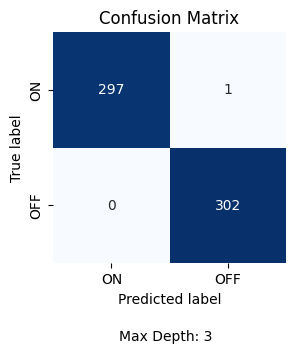

In [ ]:
# Hitung confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Tampilkan Confusion Matrix
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['ON', 'OFF'],yticklabels=['ON', 'OFF'])
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')

plt.figtext(0.5, -0.15, f"Max Depth: {forest.max_depth}", ha="center", fontsize=10)

plt.show()

AUC Score of Max Depth 3: 0.9972443219698652


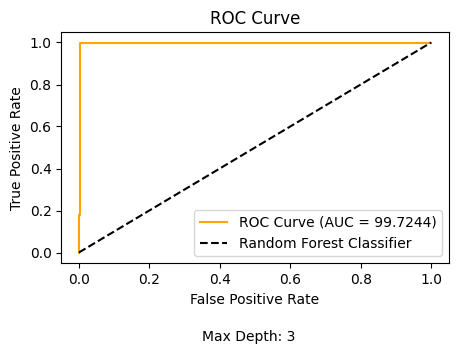

In [ ]:
# Prediksi probabilitas pada data test
# Ambil probabilitas kelas positif
y_test_proba = forest.predict_proba(X_test)[:, 1]

# Hitung AUC score sebagai metrik evaluasi
auc_score = roc_auc_score(y_test, y_test_proba)
print(f"AUC Score of Max Depth {forest.max_depth}: {auc_score}")

# Hitung nilai ROC curve (FPR & TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Visualisasi
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color='orange',
         label=f'ROC Curve (AUC = {auc_score*100:.4f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Random Forest Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.figtext(0.5, -0.15, f"Max Depth: {forest.max_depth}",
            ha="center", fontsize=10)

plt.show()

In [ ]:
# Konversi Random Forest ke C++ menggunakan micromlgen
code = micromlgen.port(forest)

# Buat file
filename = f"random_forest_classifier_m_{forest.max_depth}.h"

# Simpan file
with open(filename, "w") as f:
  f.write(code)

print(f"Konversi berhasil\nFile:{filename}\nMax Depth:{forest.max_depth}")

Konversi berhasil
File:random_forest_classifier_m_3.h
Max Depth:3
